# Photometry of M16
## Importing Modules and Libraries

In [75]:
#import packages 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
import urllib.request
import os
import gzip
import shutil
from astropy.io import fits


## Downloading FITS Image of M16

In [76]:
from astropy.utils.data import download_file

m16_url = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/ick909040_drz.fits" #URL of M16 image from the MAST Archive 
m16_file = download_file(m16_url, cache = True)
m16_file 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"

'C:\\Users\\mya\\.astropy\\cache\\download\\url\\715233a8f11bfd011439fab978a69403\\contents'

## Image Display 

In [77]:
m16_hdu_list = fits.open(m16_file) 
if 'm16.fits' not in os.listdir():
    m16_hdu_list.writeto('m16.fits')

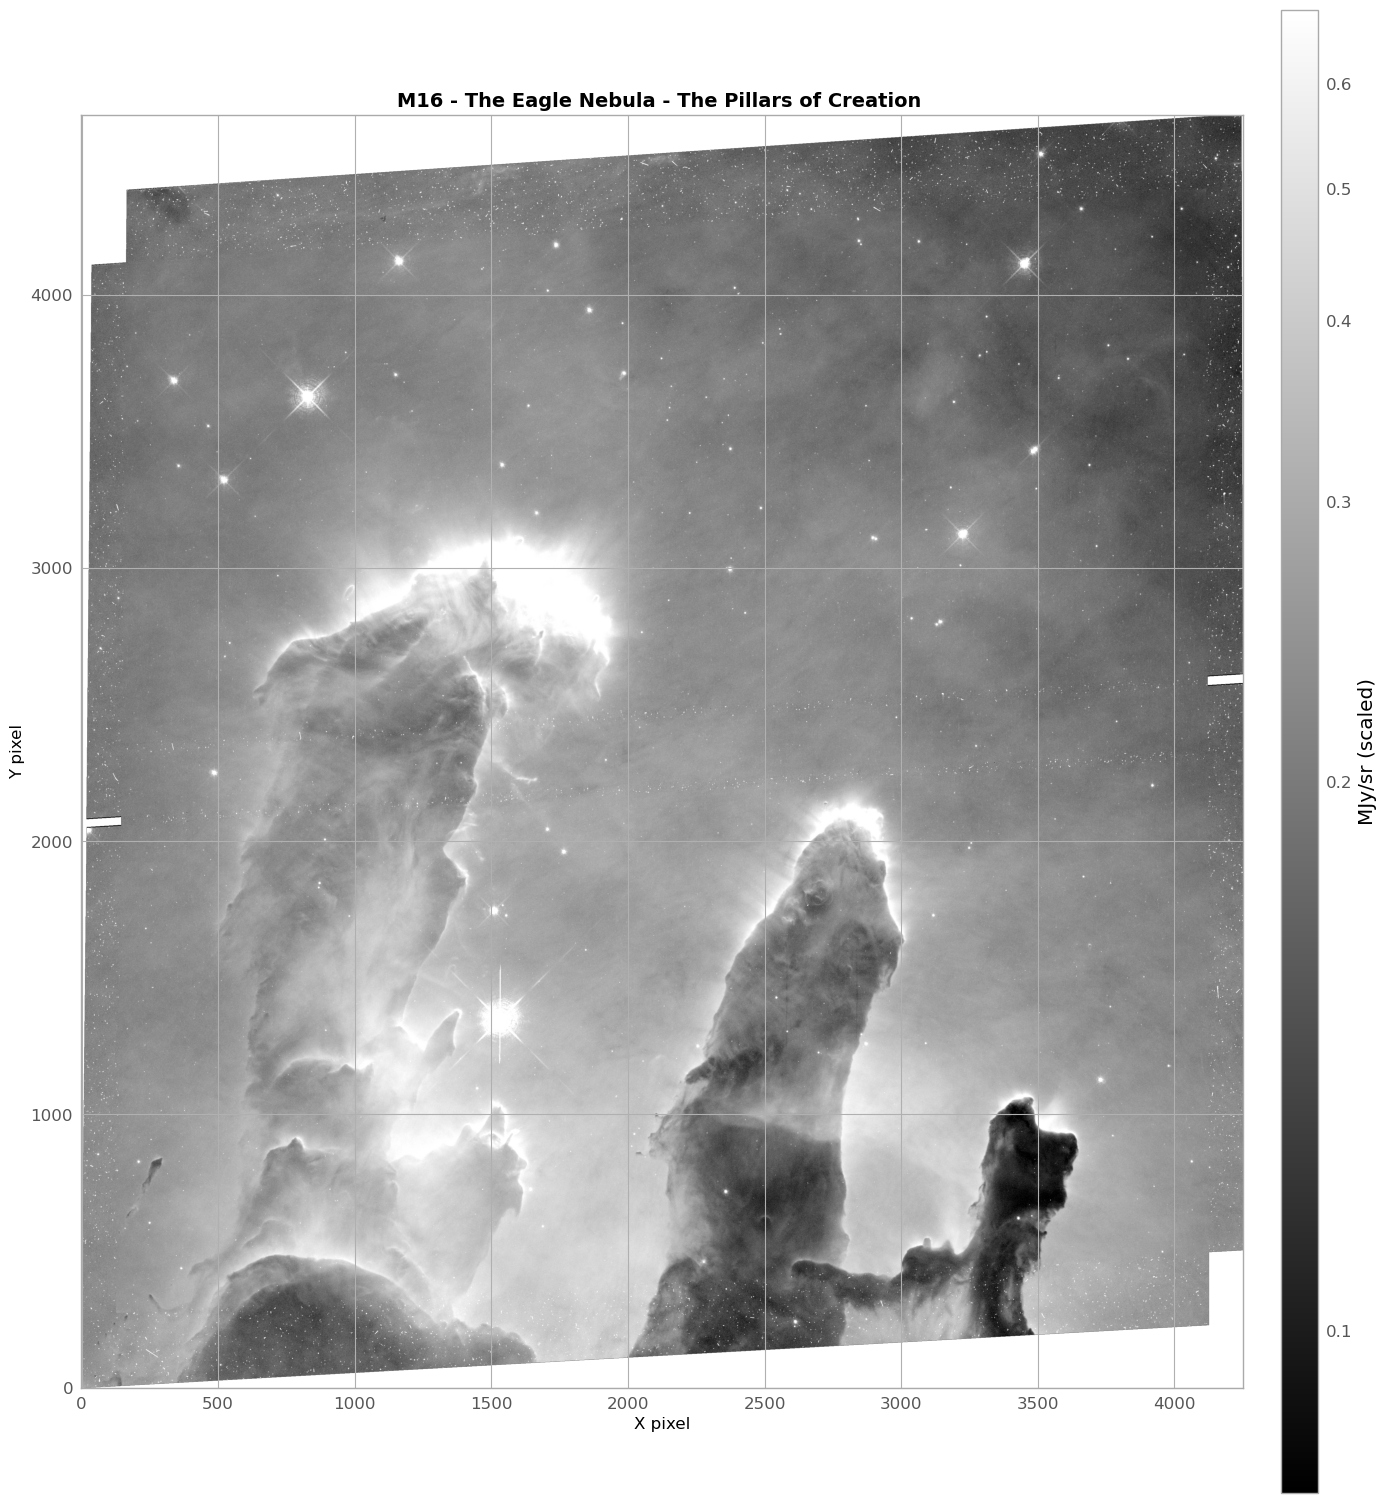

In [14]:
#Nice styling
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

m16_data = fits.getdata('m16.fits')

#Display the image
#plt.imshow(image_data, cmap='gray')
#plt.colorbar();
#Lecture 14
if os.path.exists(m16_file) and m16_data is not None:
    from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = m16_data.shape[0] / m16_data.shape[1]
    fig_width = 14
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(m16_file):
    print("Skipping visualization - no image data loaded")

## Star Detection and PSF Fitting

In [78]:
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0) #ignores outliers and NaNs 
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std) #width of PSF fit (in pixels), absolute image value above which to select sources
# find sources
sources=daofind(m16_data-median) #median (?) values of M16 DAO stats
sources

0.2401543 0.2272991 0.07263864


id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,52.46822189390466,7.847343564602002,0.9800148082672276,-0.23613808,-0.44866846296308066,25,2.2419043,7.405397,-2.1738708,-1.5649584521868587
2,24.368819413339875,10.590184137182842,0.5329167349130494,-0.076028734,0.29536722546410565,25,0.5884603,3.5991995,-1.3905149,-0.4899915414933553
3,101.44804949541975,11.095782055637738,0.6592339355078747,-0.47871473,-0.11669940748934553,25,0.48023176,2.6593432,-1.061936,-0.10033341175959357
4,283.11271989982015,20.779657463953395,0.729689794615321,-0.028768266,0.07507390685384972,25,1.233265,7.69238,-2.2151518,-0.9826093310985552
5,4.568521326491858,22.083548358981684,0.6842682368518688,0.37404314,-0.0061853153801748615,25,1.5739568,7.8247066,-2.2336702,-1.398843367231037
6,292.0459676038776,24.090777932585556,0.7226169612078409,-0.23305427,0.0898482082387888,25,3.4113278,13.332723,-2.812297,-2.251053381966938
7,234.4177922448134,24.7120313059923,0.7374129249479371,-0.33673465,0.035357963938316236,25,0.8523264,3.3729246,-1.3200165,-0.7166088934481398
8,334.66253081454676,26.73613105837058,0.5207718465668151,0.19659278,0.5137458064000316,25,0.66133064,5.1269155,-1.7746403,-0.500993994121481
9,472.09346797080127,33.08175231820102,0.5841428755646833,0.12763491,-0.020010856255060733,25,0.64947486,1.6475092,-0.5420696,-0.691887191946347


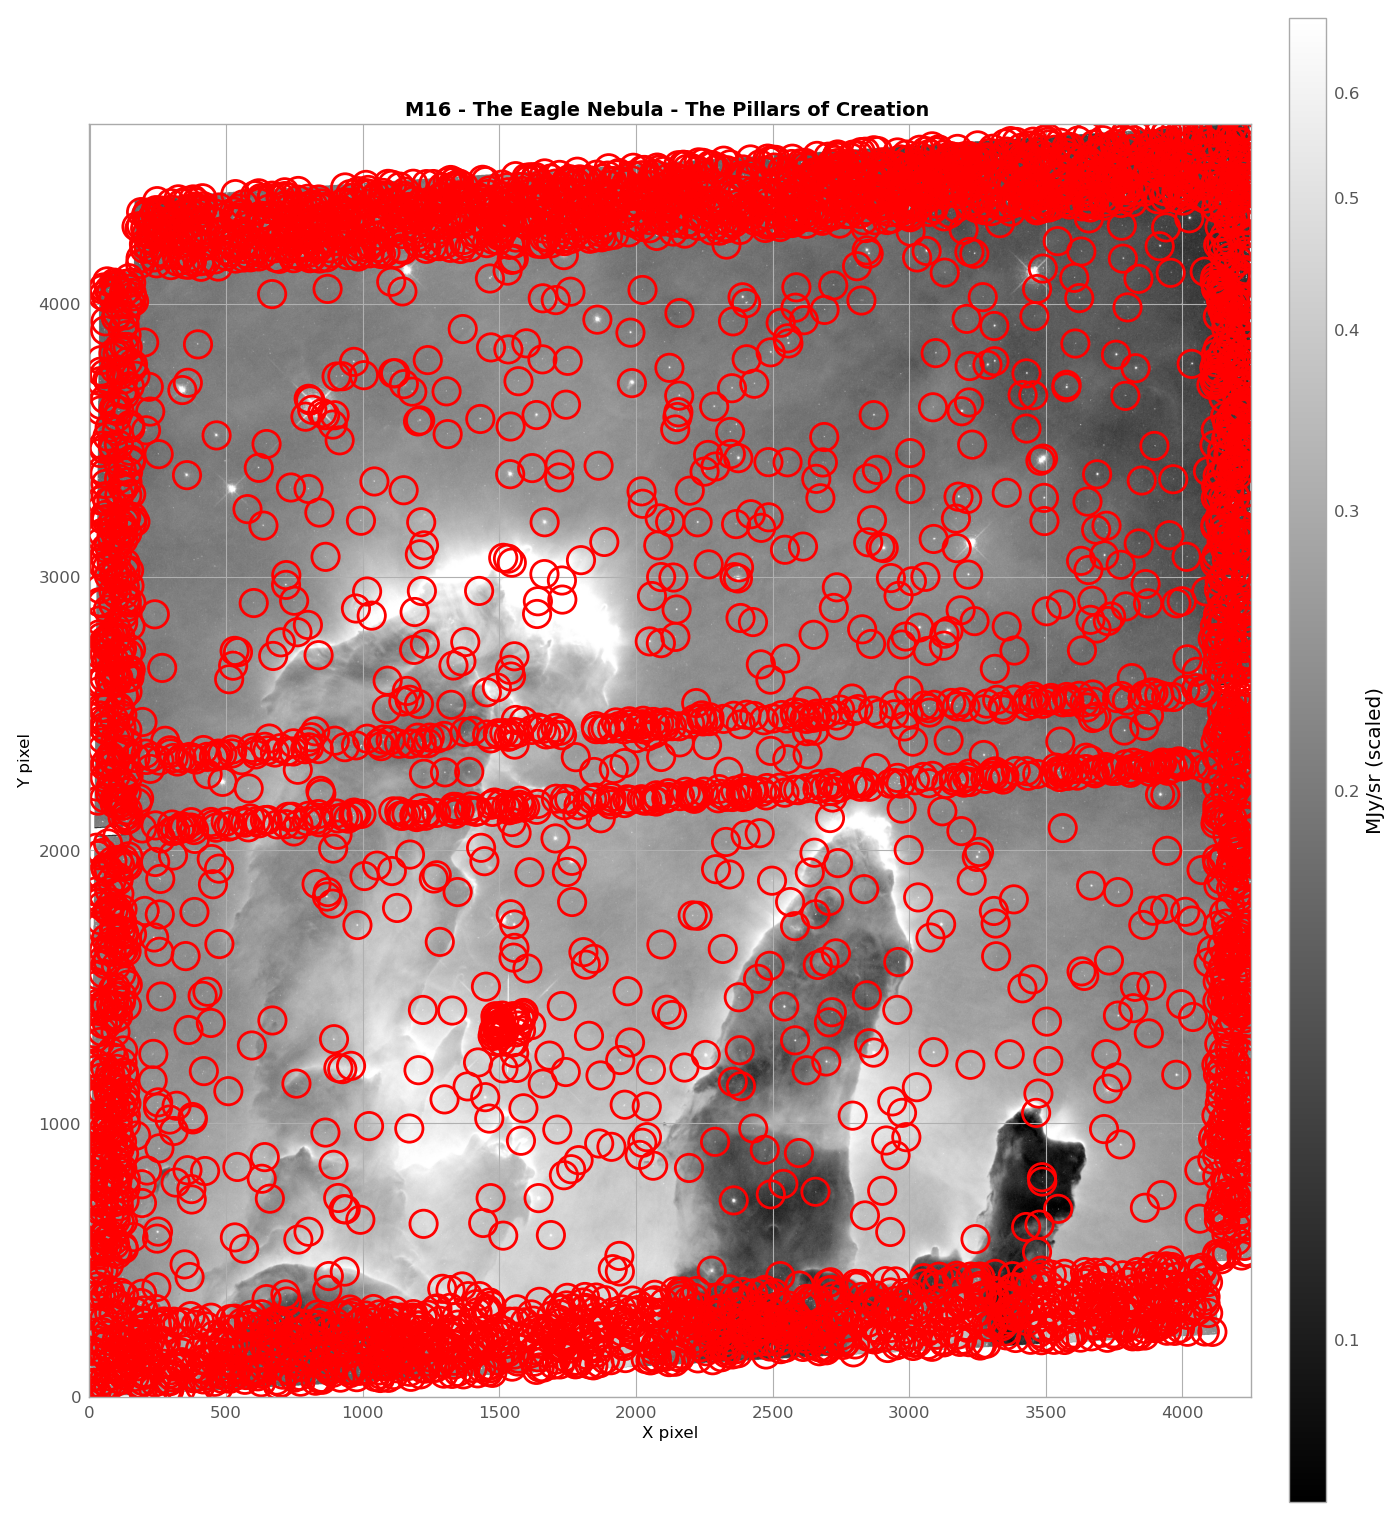

In [ ]:
%matplotlib widget
from photutils.aperture import CircularAperture #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid'])) #positions of stars from sources
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=50) #apertures around sources
apertures.plot(color='red',lw=2)

#image display


plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

### PSF Fitting 

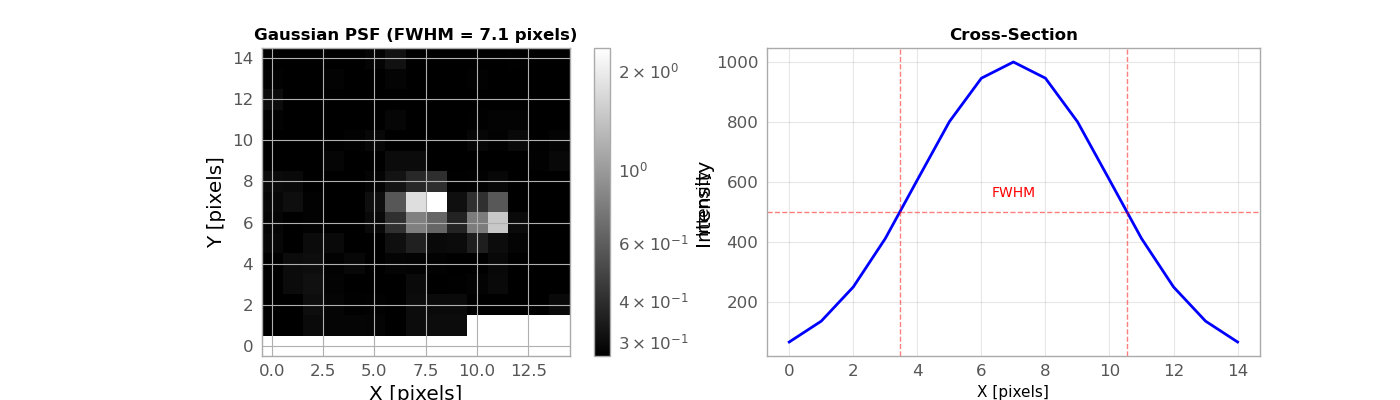

In [ ]:
from astropy.nddata.utils import Cutout2D
pixels = 15 
size = (pixels,pixels)
x = np.arange(pixels) # pixels
y = np.arange(pixels)
x_grid, y_grid = np.meshgrid(x,y)

# PSF parameters
x0, y0 = pixels // 2, pixels // 2  # Center
amplitude = 1000.0  # Peak height
sigma = 3.0  # Width parameter
x = np.arange(pixels)
# Calculate distances from center
r_squared = (x_grid - x0)**2 + (y_grid - y0)**2

# 2D Gaussian PSF
psf = amplitude * np.exp(-r_squared / (2 * sigma**2))

# Calculate FWHM
fwhm = 2.355 * sigma


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 2D image
cutout=Cutout2D(m16_data.data, (52.5,7.85), size) #values from table above 
minim=np.nanpercentile(cutout.data, 50)
maxim=np.nanpercentile(cutout.data, 99.9)
im1 = axes[0].imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log')
axes[0].set_title(f'Gaussian PSF (FWHM = {fwhm:.1f} pixels)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('X [pixels]')
axes[0].set_ylabel('Y [pixels]')
plt.colorbar(im1, ax=axes[0], label='Intensity')

center_slice = pixels // 2
axes[1].plot(x, psf[x, center_slice], 'b-', lw=2)
axes[1].axhline(amplitude / 2, color='red', ls='--', lw=1, alpha=0.5)
axes[1].axvline(x0 - fwhm/2, color='red', ls='--', lw=1, alpha=0.5)
axes[1].axvline(x0 + fwhm/2, color='red', ls='--', lw=1, alpha=0.5)
axes[1].set_xlabel('X [pixels]', fontsize=11)
axes[1].set_ylabel('Intensity', fontsize=11)
axes[1].set_title('Cross-Section', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].text(x0, amplitude*0.55, 'FWHM', ha='center', fontsize=10, color='red')




# Cross-section through center

plt.show()

In [74]:


from photutils.psf import (CircularGaussianPRF, fit_2dgaussian) #fit 2D Gaussian to a star
sources
xypos = list(zip(sources['x_centroid'], sources['y_centroid']))
psfphot = fit_2dgaussian(m16.data, xypos=xypos, fit_shape=7,
                         fix_fwhm=False)
phot_tbl = psfphot.results
len(phot_tbl)
5


NameError: name 'm16' is not defined

In [25]:

#def star_cutout(x,y,position):    
pixels=15
size=(pixels, pixels)
cutout=Cutout2D(m16_data.data, position, size)
minim=np.nanpercentile(cutout.data, 50)
maxim=np.nanpercentile(cutout.data, 99.9)
plt.imshow(cutout.data, origin=origin_pos, cmap=cmap, vmin=minim, vmax=maxim, norm='log')
plt.show()

NameError: name 'position' is not defined

## Class Implementation Test

In [8]:
import numpy as np
from scipy.optimize import curve_fit

class ClusterAnalyzer:
    """
    A class to perform PSF photometry on an astronomical image 
    of an open cluster.
    """
    
    def __init__(self, m16_file):
        """Initialize the object by loading the data."""
        self.m16_hdu_list = fits.open(m16_file)
        if 'm16.fits' not in os.listdir():
            m16_hdu_list.writeto('m16.fits')
        
        self.stars_found = [] # To store (x, y) coordinates
        self.photometry_results = [] # To store fitted (flux, x, y)
        
    def show_image(self, title="Open Cluster Field"):
        """Utility method to visualize the data."""
        if os.path.exists(self.m16_file) and self.m16_data is not None:
            from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
            norm = ImageNormalize(self.m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
            aspect_ratio = self.m16_data.shape[0] / self.m16_data.shape[1]
            fig_width = 14
            fig_height = fig_width * aspect_ratio
    
            plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
            plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
            plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
            plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
            plt.xlabel('X pixel', fontsize=12)
            plt.ylabel('Y pixel', fontsize=12)
            plt.tight_layout()
            plt.show()
        
        elif os.path.exists(m16_file):
            print("Skipping visualization - no image data loaded")
    
    @staticmethod
    def gaussian_2d(coords, amplitude, xo, yo, sigma):
        """
        A static method for the PSF model. 
        Note: The @staticmethod decorator is used to define a method inside a 
        class that does not depend on a specific instance's data or the class itself.
        """
        x, y = coords
        g = amplitude * np.exp(-((x-xo)**2 + (y-yo)**2) / (2*sigma**2))
        return g.ravel()

    def fit_star_psf(self, x_guess, y_guess, box_size=10):
        """
        Extracts a small sub-region around a guess and fits a 2D Gaussian.
        """
        # 1. Crop a small box around the star
        sub_image = self.m16_data[y_guess-box_size:y_guess+box_size, 
                                    x_guess-box_size:x_guess+box_size]
        
        # 2. Create a coordinate grid for the fit
        yp, xp = np.indices(sub_image.shape)
        
        # 3. Perform the fit
        initial_guess = (np.max(sub_image), box_size, box_size, 2.0)
        try:
            popt, _ = curve_fit(self.gaussian_2d, (xp, yp), sub_image.ravel(), p0=initial_guess)
            
            # Store results: [Flux (Amplitude), Global X, Global Y, Width]
            res = [popt[0], popt[1] + (x_guess-box_size), popt[2] + (y_guess-box_size)]
            self.photometry_results.append(res)
            return res
        except:
            print(f"Fit failed for star at {x_guess}, {y_guess}")
            return None


In [ ]:
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0)
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std)
# find sources
sources=daofind(m16_data-median)
sources

In [ ]:
from photutils.aperture import CircularAperture #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=10)
apertures.plot(color='red',lw=5)

plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
x=1550
y=400
position=(x,y)
star_1=star_cutout(x,y,position)

## Color Magnitude Diagram

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from astroquery.mast import Observations
from astroquery.mast import Catalogs
import pandas as pd
import astropy.io.fits as fits

In [68]:
m16_hdu_list.info()

Filename: C:\Users\mya\.astropy\cache\download\url\715233a8f11bfd011439fab978a69403\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     853   ()      
  1  SCI           1 ImageHDU        94   (4253, 4659)   float32   
  2  WHT           1 ImageHDU        45   (4253, 4659)   float32   
  3  CTX           1 ImageHDU        40   (4253, 4659)   int32   
  4  HDRTAB        1 BinTableHDU    561   4R x 276C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 9A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, 8A, 23A, D, D, D, D, K, K, 8A, 23A, 9A, 19A, 4A, K, D, D, D, K, K, K, K, 23A, D, D, D, D, K, K, 4A, 3A, 4A, L, D, D, D, 23A, 1A, K, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, 8A, D, D, 4A, 18A, 3A, K, 5A, 4A, D, 13A, 8A, 4A, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, D, 3A, K,

In [ ]:

magnitudes = m16_hdu_list[1].data["PSFMAG"] #potential key for accessing magnitudes from HDU list
magnitudes = np.array(magnitudes)

# Creating arrays for g-band and r-band magnitudes
g_band = magnitudes[:, 1]
r_band = magnitudes[:, 2]

# Calculating color (g - r)
color_data1 = g_band - r_band

# Plotting the CMD
plt.figure(figsize=(8, 6))
plt.scatter(color_data1, r_band, s=3, color="black", label="M13 data")
plt.ylim(10, 30)
plt.gca().invert_yaxis()
plt.xlim(-2, 2)
plt.title("CMD of M16")
plt.ylabel("Apparent Magnitude (r-band)")
plt.xlabel("Color (g - r)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [84]:
print(m16_hdu_list[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2025-08-14'         / date this file was written (yyyy-mm-dd)        COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H NEXTEND =                    4 / Number of standard extensions                  FILENAME= 'ick909040_drz.fits' / name of file                                   FILETYPE= 'SCI      '          / type of data found in data file                                                                                                TELESCOP= 'HST'                / telescope used to acquire data                 BSIDEOPS= 'FALSE'              / Post-20